In [1]:
import os
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rioxarray as rio
import geopandas as gpd

In [2]:
sRenalysisP = '/g100_work/IscrC_IT-WATER/data_CMCC/reanalysis/P'
sRcp45P = '/g100_work/IscrC_IT-WATER/data_CMCC/rcp45/P'
sRcp85P = '/g100_work/IscrC_IT-WATER/data_CMCC/rcp85/P'

In [3]:
asRenalysisP = os.listdir(sRenalysisP)
asRenalysisP.sort()

In [4]:
for sYearFolder in asRenalysisP:
    aoDailySum = []
    sYearPath = sRenalysisP+'/'+sYearFolder
    asNcRenalysisP = os.listdir(sYearPath)
    for sNcRenalysisP in asNcRenalysisP:
        xrPrecipitation = xr.open_dataset(sYearPath+'/'+sNcRenalysisP, engine="netcdf4")
        xrDailySum = xrPrecipitation.Rain.sum(dim=['nt'])
        aoDailySum.append(xrDailySum)
    oResultDailySum = sum(aoDailySum)
    oResultDailySum.to_netcdf("./results_precipitation/results_daily_sum_"+sYearFolder+".nc")

In [3]:
asRcp45P = os.listdir(sRcp45P)
asRcp45P.sort()

In [4]:
for sYearFolder in asRcp45P:
    aoDailySum = []
    sYearPath = sRcp45P+'/'+sYearFolder
    asNcRcp45P = os.listdir(sYearPath)
    for sNcRcp45P in asNcRcp45P:
        xrPrecipitation = xr.open_dataset(sYearPath+'/'+sNcRcp45P, engine="netcdf4")
        xrDailySum = xrPrecipitation.Rain.sum(dim=['nt'])
        aoDailySum.append(xrDailySum)
    oResultDailySum = sum(aoDailySum)
    oResultDailySum.to_netcdf("./results_precipitation/rcp45/results_daily_sum_rcp45_"+sYearFolder+".nc")

In [5]:
asRcp85P = os.listdir(sRcp85P)
asRcp85P.sort()

In [6]:
for sYearFolder in asRcp85P:
    aoDailySum = []
    sYearPath = sRcp85P+'/'+sYearFolder
    asNcRcp85P = os.listdir(sYearPath)
    for sNcRcp85P in asNcRcp85P:
        xrPrecipitation = xr.open_dataset(sYearPath+'/'+sNcRcp85P, engine="netcdf4")
        xrDailySum = xrPrecipitation.Rain.sum(dim=['nt'])
        aoDailySum.append(xrDailySum)
    oResultDailySum = sum(aoDailySum)
    oResultDailySum.to_netcdf("./results_precipitation/rcp85/results_daily_sum_rcp85_"+sYearFolder+".nc")

In [2]:
sRcp85ForMeanP = './results_precipitation/rcp85/'
sRcp45ForMeanP = './results_precipitation/rcp45/'
sReanalysisForMeanP = './results_precipitation/reanalysis/'

In [3]:
asRcp85ForMeanP = os.listdir(sRcp85ForMeanP)
asRcp85ForMeanP.sort()

In [4]:
aoYearlyMeanRcp85 = []
for sFileRcp85 in asRcp85ForMeanP:
    if '.nc' in sFileRcp85:
        xrYearlyMeanRcp85 = xr.open_dataset(sRcp85ForMeanP+'/'+sFileRcp85, engine="netcdf4")
        aoYearlyMeanRcp85.append(xrYearlyMeanRcp85)

In [6]:
oResultYearlyMeanRcp85 = sum(aoYearlyMeanRcp85) / len(aoYearlyMeanRcp85)
oResultYearlyMeanRcp85.to_netcdf("./results_precipitation/rcp85/yearly_mean/results_yearly_mean_precipitation_rcp85.nc")

In [7]:
asRcp45ForMeanP = os.listdir(sRcp45ForMeanP)
asRcp45ForMeanP.sort()

In [8]:
aoYearlyMeanRcp45 = []
for sFileRcp45 in asRcp45ForMeanP:
    if '.nc' in sFileRcp45:
        xrYearlyMeanRcp45 = xr.open_dataset(sRcp45ForMeanP+'/'+sFileRcp45, engine="netcdf4")
        aoYearlyMeanRcp45.append(xrYearlyMeanRcp45)

In [10]:
oResultYearlyMeanRcp45 = sum(aoYearlyMeanRcp45) / len(aoYearlyMeanRcp45)
oResultYearlyMeanRcp45.to_netcdf("./results_precipitation/rcp45/yearly_mean/results_yearly_mean_precipitation_rcp45.nc")

In [11]:
asReanalysisForMeanP = os.listdir(sReanalysisForMeanP)
asReanalysisForMeanP.sort()

In [12]:
aoYearlyMeanReanalysis = []
for sFileReanalysis in asReanalysisForMeanP:
    if '.nc' in sFileReanalysis:
        xrYearlyMeanReanalysis = xr.open_dataset(sReanalysisForMeanP+'/'+sFileReanalysis, engine="netcdf4")
        aoYearlyMeanReanalysis.append(xrYearlyMeanReanalysis)

In [13]:
oResultYearlyMeanReanalysis = sum(aoYearlyMeanReanalysis) / len(aoYearlyMeanReanalysis)
oResultYearlyMeanReanalysis.to_netcdf("./results_precipitation/reanalysis/yearly_mean/results_yearly_mean_precipitation_reanalysis.nc")

In [14]:
oYearlyRcp85 = xr.open_dataset("./results_precipitation/rcp85/yearly_mean/results_yearly_mean_precipitation_rcp85.nc", engine="netcdf4")
oYearlyRcp45 = xr.open_dataset("./results_precipitation/rcp45/yearly_mean/results_yearly_mean_precipitation_rcp45.nc", engine="netcdf4")
oYearlyReanalysis = xr.open_dataset("./results_precipitation/reanalysis/yearly_mean/results_yearly_mean_precipitation_reanalysis.nc", engine="netcdf4")

In [15]:
oRcp85Reanalysis = ((oYearlyRcp85 - oYearlyReanalysis) / oYearlyReanalysis) * 100

In [16]:
oRcp45Reanalysis = ((oYearlyRcp45 - oYearlyReanalysis) / oYearlyReanalysis) * 100

In [17]:
oRcp85Reanalysis.to_netcdf("./results_precipitation/final_results/rcp85ReanalysisPrecipitation.nc")
oRcp45Reanalysis.to_netcdf("./results_precipitation/final_results/rcp45ReanalysisPrecipitation.nc")

In [18]:
oRcp85Reanalysis = xr.open_dataset("./results_precipitation/final_results/rcp85ReanalysisPrecipitation.nc", engine="netcdf4")

In [19]:
shapefile_path = r'ITA_adm1.shp'
gdf = gpd.read_file(shapefile_path)

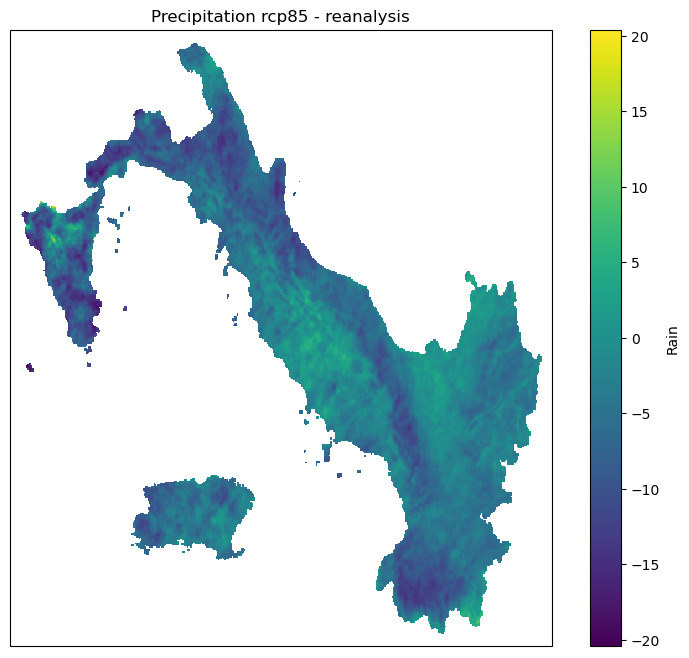

In [26]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp85Reanalysis['Rain'].plot.pcolormesh(ax=ax, cmap='viridis', transform=ccrs.PlateCarree())
ax.set_title('Precipitation rcp85 - reanalysis')
plt.show()

In [21]:
oRcp45Reanalysis = xr.open_dataset("./results_precipitation/final_results/rcp45ReanalysisPrecipitation.nc", engine="netcdf4")

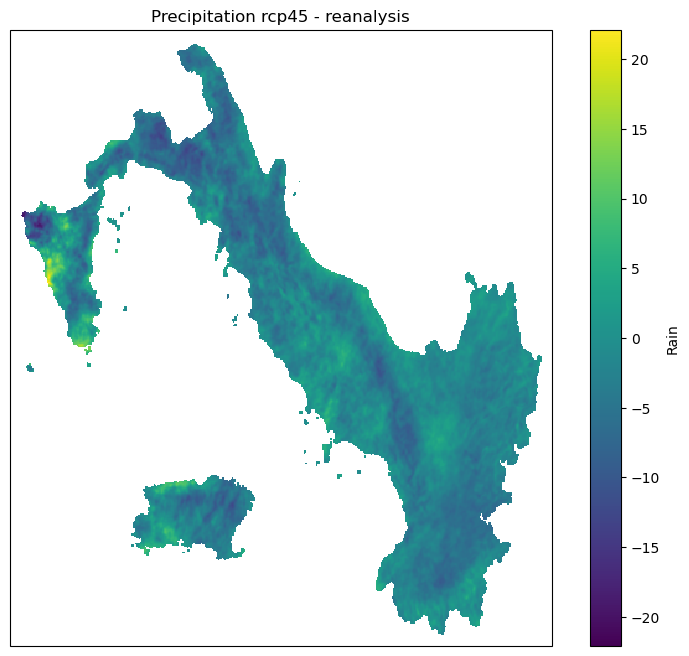

In [27]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp45Reanalysis['Rain'].plot.pcolormesh(ax=ax, cmap='viridis', transform=ccrs.PlateCarree())
ax.set_title('Precipitation rcp45 - reanalysis')
plt.show()

In [28]:
gdf

,ID_0,ISO,NAME_0,ID_1,NAME_1,TYPE_1,ENGTYPE_1,NL_NAME_1,VARNAME_1,geometry
0,112,ITA,Italy,1,Abruzzo,Regione,Region,None,Abruzos|Abruzzen|Abruzzes|Abruzzi,"POLYGON ((13.91542 42.89561, 13.91542 42.89542..."
1,112,ITA,Italy,2,Apulia,Regione,Region,None,Apulien|Pouilles|Pouille|Puglia|Puglie,"MULTIPOLYGON (((17.94931 40.05375, 17.94931 40..."
2,112,ITA,Italy,3,Basilicata,Regione,Region,None,Basilicate|Lucania,"MULTIPOLYGON (((15.71736 39.96792, 15.71736 39..."
3,112,ITA,Italy,4,Calabria,Regione,Region,None,Calabre|Calabrie|Kalabrien,"MULTIPOLYGON (((15.80208 39.70014, 15.80208 39..."
4,112,ITA,Italy,5,Campania,Regione,Region,None,Campanha|Campanie|Kampanien,"MULTIPOLYGON (((14.25264 40.54153, 14.25264 40..."
5,112,ITA,Italy,6,Emilia-Romagna,Regione,Region,None,Emilia Romagna|Emilia|Emilia-Romaña|Émilie-Rom...,"MULTIPOLYGON (((12.4059 43.89975, 12.406 43.89..."
6,112,ITA,Italy,7,Friuli-Venezia Giulia,Regione,Autonomous Region,None,Friuli Venezia Giulia|Friuli-Venecia Julia,"MULTIPOLYGON (((13.31625 45.69347, 13.31625 45..."
7,112,ITA,Italy,8,Lazio,Regione,Region,None,Lacio|Latium,"MULTIPOLYGON (((13.45514 40.79264, 13.45514 40..."
8,112,ITA,Italy,9,Liguria,Regione,Region,None,Ligurie|Ligurien,"MULTIPOLYGON (((8.22597 44.02736, 8.22597 44.0..."
9,112,ITA,Italy,10,Lombardia,Regione,Region,None,Lombardy|Lombardei|Lombardie,"MULTIPOLYGON (((8.81457 45.01818, 8.81401 45.0..."


In [30]:
oSicilia = gdf[gdf['NAME_1'] == 'Sicily']
oSicilia

,ID_0,ISO,NAME_0,ID_1,NAME_1,TYPE_1,ENGTYPE_1,NL_NAME_1,VARNAME_1,geometry
14,112,ITA,Italy,15,Sicily,Regione,Autonomous Region,None,Sicilia,"MULTIPOLYGON (((12.53764 35.52986, 12.53764 35..."


In [31]:
oSicilia = oSicilia.reset_index(drop=True)
oSicilia

,ID_0,ISO,NAME_0,ID_1,NAME_1,TYPE_1,ENGTYPE_1,NL_NAME_1,VARNAME_1,geometry
0,112,ITA,Italy,15,Sicily,Regione,Autonomous Region,None,Sicilia,"MULTIPOLYGON (((12.53764 35.52986, 12.53764 35..."


In [32]:
dataRcp45Reanalysis = oRcp45Reanalysis.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
dataRcp45Reanalysis = oRcp45Reanalysis.rio.write_crs("epsg:4326", inplace=True)

In [33]:
oSicilia = oSicilia.to_crs(dataRcp45Reanalysis.rio.crs)

In [34]:
oSiciliaGeometries = oSicilia.geometry

In [35]:
oClippedData = dataRcp45Reanalysis.rio.clip(oSiciliaGeometries, oSicilia.crs)

In [36]:
output_path = r'./results_precipitation/final_results/rcp45ReanalysisSicliaPrecipitation.nc'
oClippedData.to_netcdf(output_path)

In [37]:
oRcp45ReanalysisSicilia = xr.open_dataset("./results_precipitation/final_results/rcp45ReanalysisSicliaPrecipitation.nc", engine="netcdf4")

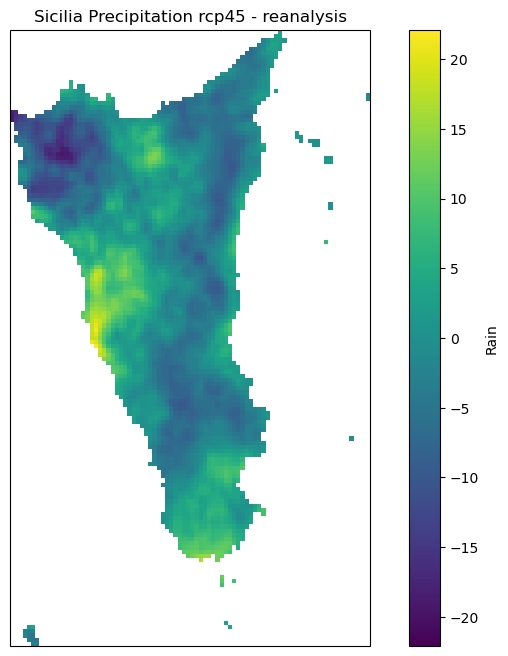

In [38]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp45ReanalysisSicilia['Rain'].plot.pcolormesh(ax=ax, cmap='viridis', transform=ccrs.PlateCarree())
ax.set_title('Sicilia Precipitation rcp45 - reanalysis')
plt.show()

In [39]:
dataRcp85Reanalysis = oRcp85Reanalysis.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
dataRcp85Reanalysis = oRcp85Reanalysis.rio.write_crs("epsg:4326", inplace=True)

In [40]:
oClippedDataRcp85 = dataRcp85Reanalysis.rio.clip(oSiciliaGeometries, oSicilia.crs)

In [41]:
output_path_85 = r'./results_precipitation/final_results/rcp85ReanalysisSiciliaPrecipitation.nc'
oClippedDataRcp85.to_netcdf(output_path_85)

In [42]:
oRcp85ReanalysisSicilia = xr.open_dataset("./results_precipitation/final_results/rcp85ReanalysisSiciliaPrecipitation.nc", engine="netcdf4")

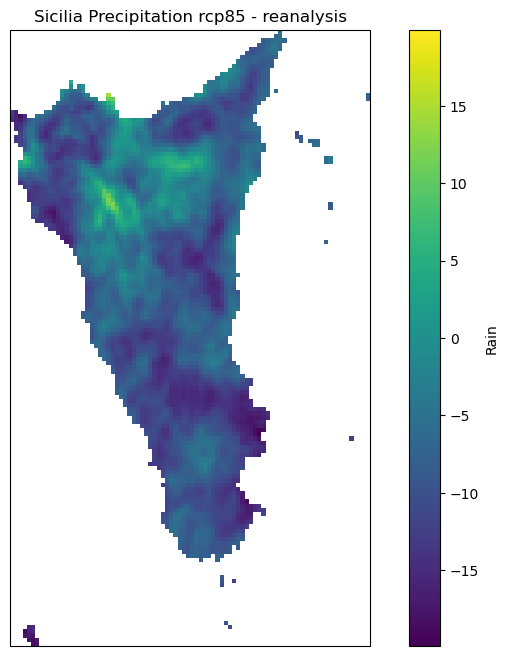

In [43]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp85ReanalysisSicilia['Rain'].plot.pcolormesh(ax=ax, cmap='viridis', transform=ccrs.PlateCarree())
ax.set_title('Sicilia Precipitation rcp85 - reanalysis')
plt.show()